# NumPy for Data Analytics — Core Concepts & Operations

**Author:** Aketch Adhiambo Okoth    
**Institution:** Montclair State University  

---

## Overview

NumPy (Numerical Python) is the foundational library for scientific computing in Python. This notebook covers the complete core toolkit used in data analytics workflows:

| Section | Topics Covered |
|---|---|
| **1. Creating Arrays** | `np.array`, `np.zeros`, `np.ones`, `np.arange`, `np.linspace` |
| **2. N-Dimensions** | shape, ndim, size, 1D / 2D / 3D arrays |
| **3. Reshape** | `reshape()`, flattening, dimension conversion |
| **4. Slicing** | Indexing, row/column selection, sub-arrays |
| **5. Filtering** | Boolean masks, compound conditions |
| **6. View vs. Copy** | Memory behaviour, `copy()` |
| **7. Introspection** | `max`, `min`, `sum`, `mean`, `std` with axis control |
| **8. Element-wise Ops** | Vectorized arithmetic vs. Python lists |
| **9. Data Types** | `dtype`, type coercion, `int8` constraints |
| **10. Broadcasting** | Shape compatibility rules, scalar/vector/matrix ops |
| **11. DataFrames → Arrays** | `to_numpy()`, `select_dtypes`, `nanmean` |

**Why NumPy matters:** NumPy arrays are implemented in C, giving them dramatically faster execution and lower memory overhead than native Python lists. Operations on entire arrays execute without explicit loops — a design pattern called *vectorization* that underlies pandas, scikit-learn, and every major ML library.

In [1]:
# Core imports — loaded once for the entire notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'axes.titlesize': 11, 'axes.titleweight': 'bold',
                     'figure.dpi': 110, 'axes.labelsize': 10})

np.random.seed(0)  # reproducibility
print('NumPy version :', np.__version__)
print('Imports successful.')

NumPy version : 2.0.2
Imports successful.


---
## 1. Creating Arrays

NumPy provides multiple factory functions for array creation. Each targets a different use case — from manual data entry to generating evenly spaced sequences for mathematical modeling.

In [2]:
#From a Python list
a1 = np.array([1, 2, 3])
print('np.array([1,2,3])   :', a1)

# Zeros and Ones
print('np.zeros(3)         :', np.zeros(3))
print('np.ones(3)          :', np.ones(3))

# Integer ranges
print('np.arange(3)        :', np.arange(3))           # 0, 1, 2
print('np.arange(0,12,3)   :', np.arange(0, 12, 3))    # step of 3

# Evenly spaced floats
lin = np.linspace(0, 1, 5)
print('np.linspace(0,1,5)  :', lin)                    # 5 points from 0 to 1 inclusive

np.array([1,2,3])   : [1 2 3]
np.zeros(3)         : [0. 0. 0.]
np.ones(3)          : [1. 1. 1.]
np.arange(3)        : [0 1 2]
np.arange(0,12,3)   : [0 3 6 9]
np.linspace(0,1,5)  : [0.   0.25 0.5  0.75 1.  ]


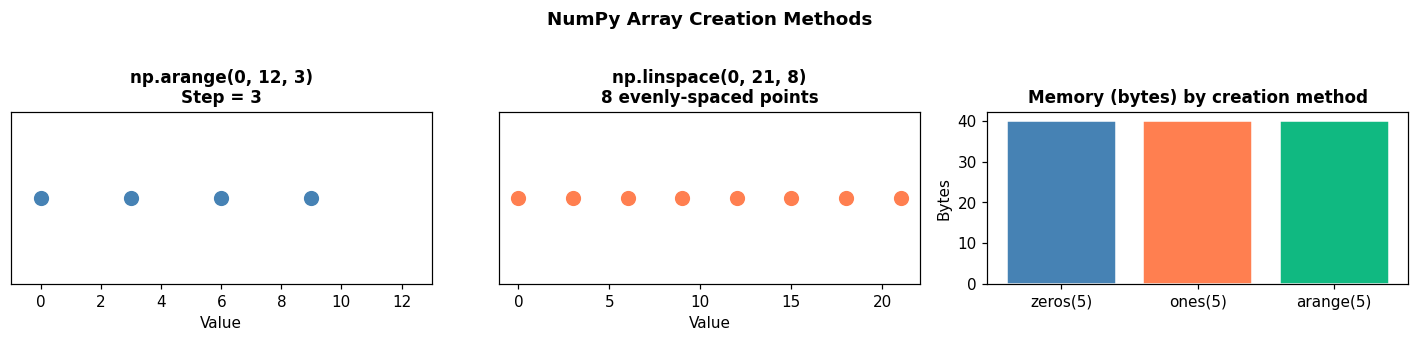

In [3]:
# Visualise the three common range-creation methods
fig, axes = plt.subplots(1, 3, figsize=(13, 3))

axes[0].scatter(np.arange(0, 12, 3), np.zeros(4), s=80, color='steelblue')
axes[0].set_title('np.arange(0, 12, 3)\nStep = 3'); axes[0].set_yticks([])
axes[0].set_xlabel('Value'); axes[0].set_xlim(-1, 13)

pts = np.linspace(0, 21, 8)
axes[1].scatter(pts, np.zeros(8), s=80, color='coral')
axes[1].set_title('np.linspace(0, 21, 8)\n8 evenly-spaced points'); axes[1].set_yticks([])
axes[1].set_xlabel('Value')

sizes = [np.zeros(5).nbytes, np.ones(5).nbytes, np.arange(5).nbytes]
axes[2].bar(['zeros(5)', 'ones(5)', 'arange(5)'], sizes,
            color=['steelblue', 'coral', '#10B981'], edgecolor='white')
axes[2].set_title('Memory (bytes) by creation method')
axes[2].set_ylabel('Bytes')

plt.suptitle('NumPy Array Creation Methods', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('np_creation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. N-Dimensions — Shape, Size, and ndim

Every NumPy array has three key attributes:
- **`shape`** — a tuple describing the size along each axis
- **`ndim`** — number of axes (dimensions)
- **`size`** — total number of elements

In [4]:
#  1-D array
array_onedim = np.arange(21)
print('1-D array         :', array_onedim)
print('type              :', type(array_onedim))
print('shape             :', array_onedim.shape)
print('ndim              :', array_onedim.ndim)
print('size              :', array_onedim.size)

1-D array         : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
type              : <class 'numpy.ndarray'>
shape             : (21,)
ndim              : 1
size              : 21


In [5]:
# 2-D array from list of lists
list_o_lists = [[1, 2, 3], [4, 5, 6], [7, 8, 9]]
array_twodim = np.array(list_o_lists)
print('2-D array:\n', array_twodim)
print('shape             :', array_twodim.shape)
print('ndim              :', array_twodim.ndim)
print('size              :', array_twodim.size)

2-D array:
 [[1 2 3]
 [4 5 6]
 [7 8 9]]
shape             : (3, 3)
ndim              : 2
size              : 9


---
## 3. Reshape — Converting Between Dimensions

`reshape()` rearranges the same data into a new shape **without copying memory** (it returns a view). The total number of elements must remain identical — `rows × cols × ...` must equal the original `size`.

In [6]:
# Start with a 1-D array of 12 elements
array_onedim = np.arange(12)
print('Original 1-D (12 elements):')
print(array_onedim)

# Reshape to 2-D: 3 rows × 4 cols = 12 elements ✓
array_twodim = array_onedim.reshape(3, 4)
print('\nReshaped to (3, 4):')
print(array_twodim)

# Flatten back to 1-D
print('\nFlattened back to 1-D:')
print(array_twodim.reshape(12))

Original 1-D (12 elements):
[ 0  1  2  3  4  5  6  7  8  9 10 11]

Reshaped to (3, 4):
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

Flattened back to 1-D:
[ 0  1  2  3  4  5  6  7  8  9 10 11]


In [7]:
# Reshape to 3-D: 2 × 2 × 3 = 12 elements ✓
array_threedim = array_twodim.reshape(2, 2, 3)
print('Reshaped to (2, 2, 3):')
print(array_threedim)
print('ndim              :', array_threedim.ndim)
print('shape             :', array_threedim.shape)

# Alternative 3-D: 2 × 3 × 2 = 12 elements ✓
print('\nReshaped to (2, 3, 2):')
print(array_twodim.reshape(2, 3, 2))

Reshaped to (2, 2, 3):
[[[ 0  1  2]
  [ 3  4  5]]

 [[ 6  7  8]
  [ 9 10 11]]]
ndim              : 3
shape             : (2, 2, 3)

Reshaped to (2, 3, 2):
[[[ 0  1]
  [ 2  3]
  [ 4  5]]

 [[ 6  7]
  [ 8  9]
  [10 11]]]


In [8]:
# Demonstrate the ValueError when element count does not match
# 12 elements cannot fit into 2x3=6 elements → ValueError
try:
    array_twodim.reshape(2, 3)   # 2×3 = 6 ≠ 12
except ValueError as e:
    print(f'ValueError caught: {e}')
    print('Rule: total elements must be preserved across reshape.')

ValueError caught: cannot reshape array of size 12 into shape (2,3)
Rule: total elements must be preserved across reshape.


---
## 4. Slicing — Indexing 1-D and 2-D Arrays

NumPy slicing syntax: `array[row_slice, col_slice]`. Negative indices count from the end. All slicing produces **views** of the original data (no copy unless requested).

In [9]:
# 1-D slicing
array_onedim = np.arange(21)
print('Full 1-D array     :', array_onedim)
print('Index 3            :', array_onedim[3])        # single element
print('Last element [-1]  :', array_onedim[-1])       # negative index
print('Slice [3:9]        :', array_onedim[3:9])      # elements 3–8

Full 1-D array     : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
Index 3            : 3
Last element [-1]  : 20
Slice [3:9]        : [3 4 5 6 7 8]


In [10]:
# 2-D slicing
array_twodim = np.arange(21).reshape(3, 7)
print('2-D array (3×7):')
print(array_twodim)
print()
print('Third row [2]      :', array_twodim[2])
print('Element [2, 3]     :', array_twodim[2, 3])     # row 2, col 3
print('First 2 rows [0:2]:')
print(array_twodim[0:2])
print('Column 3 [:, 3]    :', array_twodim[:, 3])     # all rows, col 3
print('Rows 0-1, last 3 cols [0:2, -3:]:')
print(array_twodim[0:2, -3:])

2-D array (3×7):
[[ 0  1  2  3  4  5  6]
 [ 7  8  9 10 11 12 13]
 [14 15 16 17 18 19 20]]

Third row [2]      : [14 15 16 17 18 19 20]
Element [2, 3]     : 17
First 2 rows [0:2]:
[[ 0  1  2  3  4  5  6]
 [ 7  8  9 10 11 12 13]]
Column 3 [:, 3]    : [ 3 10 17]
Rows 0-1, last 3 cols [0:2, -3:]:
[[ 4  5  6]
 [11 12 13]]


In [11]:
# In-place modification via slicing
array_twodim = np.arange(21).reshape(3, 7)
print('Before modification:')
print(array_twodim)

array_twodim[0, 0] = 33              # single element update
array_twodim[1:, :3] = 0            # set bottom-left 2×3 block to 0
print('\nAfter [0,0]=33 and [1:, :3]=0:')
print(array_twodim)

Before modification:
[[ 0  1  2  3  4  5  6]
 [ 7  8  9 10 11 12 13]
 [14 15 16 17 18 19 20]]

After [0,0]=33 and [1:, :3]=0:
[[33  1  2  3  4  5  6]
 [ 0  0  0 10 11 12 13]
 [ 0  0  0 17 18 19 20]]


---
## 5. Filtering — Boolean Masks

Boolean masking applies an array of `True`/`False` values to select elements. The result is always **1-D** (flattened to matching elements). Compound conditions combine masks with `&` (AND) and `|` (OR).

In [12]:
array_twodim = np.arange(21).reshape(3, 7)
print('Array to filter:')
print(array_twodim)
print()

# Manual boolean mask
mask = np.array([
    [True, False, True, True, False, True, False],
    [True, False, True, True, False, True, False],
    [True, False, True, True, False, True, False]
])
print('Manual mask result :', array_twodim[mask])

Array to filter:
[[ 0  1  2  3  4  5  6]
 [ 7  8  9 10 11 12 13]
 [14 15 16 17 18 19 20]]

Manual mask result : [ 0  2  3  5  7  9 10 12 14 16 17 19]


In [13]:
# Condition-based mask: elements < 5
mask = array_twodim < 5
print('Mask (elements < 5):')
print(mask)
print('Elements < 5       :', array_twodim[mask])
print()

# Compound condition: elements < 5 AND even
mask_compound = (array_twodim < 5) & (array_twodim % 2 == 0)
print('Mask (< 5 AND even):')
print(mask_compound)
print('Elements < 5 & even:', array_twodim[mask_compound])

Mask (elements < 5):
[[ True  True  True  True  True False False]
 [False False False False False False False]
 [False False False False False False False]]
Elements < 5       : [0 1 2 3 4]

Mask (< 5 AND even):
[[ True False  True False  True False False]
 [False False False False False False False]
 [False False False False False False False]]
Elements < 5 & even: [0 2 4]


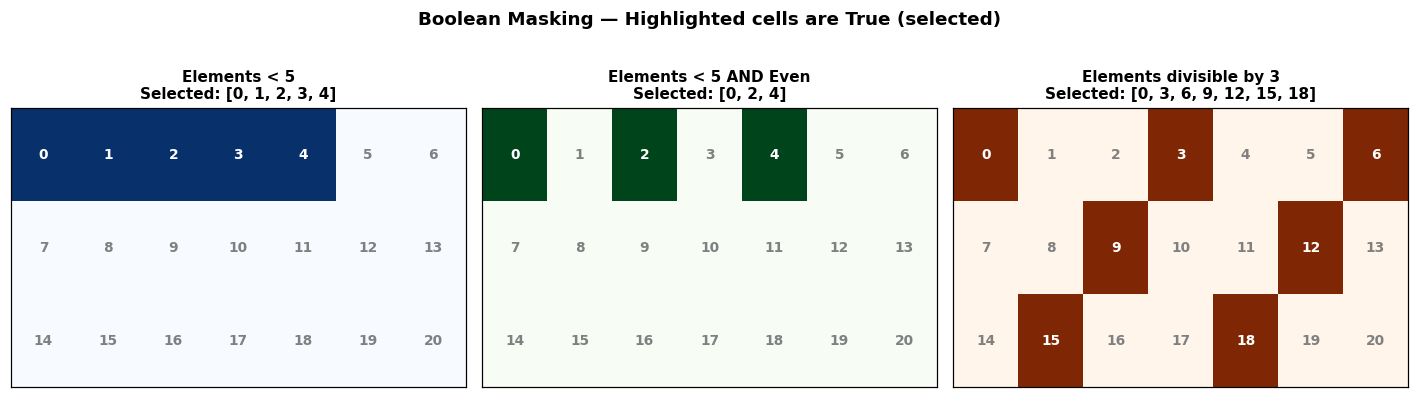

In [14]:
# Visualization: boolean masking on a 3×7 grid
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

arr = np.arange(21).reshape(3, 7)

masks_info = [
    (arr < 5,               'Elements < 5',         'Blues'),
    ((arr < 5) & (arr % 2 == 0), 'Elements < 5 AND Even', 'Greens'),
    (arr % 3 == 0,          'Elements divisible by 3', 'Oranges'),
]

for ax, (m, title, cmap) in zip(axes, masks_info):
    im = ax.imshow(m.astype(int), cmap=cmap, aspect='auto', vmin=0, vmax=1)
    for r in range(3):
        for c in range(7):
            val = arr[r, c]
            color = 'white' if m[r, c] else 'gray'
            ax.text(c, r, str(val), ha='center', va='center', fontsize=9,
                    fontweight='bold', color=color)
    ax.set_title(f'{title}\nSelected: {arr[m].tolist()}', fontsize=10, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Boolean Masking — Highlighted cells are True (selected)', y=1.02,
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('np_filtering.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. View vs. Copy — Understanding Memory Behaviour

**Critical distinction in NumPy:**
- A **view** shares the same underlying memory as the original array. Modifying the view modifies the original.
- A **copy** is an independent duplicate. Changes to the copy do not affect the original.

Slicing always returns a **view**. Use `.copy()` explicitly when you need independence.

In [15]:
#  VIEW: modifying data2 modifies data1
data1 = np.arange(24).reshape(4, 6)
print('data1 (original):')
print(data1)

data2 = data1[:2, 3:]            # slice → VIEW (shared memory)
print('\ndata2 (view of data1[:2, 3:]):')
print(data2)

data2[1, 2] = -1                 # modify the view
print('\ndata2 after data2[1,2] = -1:')
print(data2)
print('\ndata1 ALSO changed (shared memory):')
print(data1)

data1 (original):
[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]
 [12 13 14 15 16 17]
 [18 19 20 21 22 23]]

data2 (view of data1[:2, 3:]):
[[ 3  4  5]
 [ 9 10 11]]

data2 after data2[1,2] = -1:
[[ 3  4  5]
 [ 9 10 -1]]

data1 ALSO changed (shared memory):
[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 -1]
 [12 13 14 15 16 17]
 [18 19 20 21 22 23]]


In [16]:
#  COPY: modifying data2 does NOT affect data1
data1 = np.arange(24).reshape(4, 6)
print('data1 (original):')
print(data1)

data2 = data1[:2, 3:].copy()    # .copy() → independent duplicate
print('\ndata2 (independent copy of data1[:2, 3:]):')
print(data2)

data2[1, 2] = -1
print('\ndata2 after data2[1,2] = -1:')
print(data2)
print('\ndata1 is UNCHANGED (independent memory):')
print(data1)

data1 (original):
[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]
 [12 13 14 15 16 17]
 [18 19 20 21 22 23]]

data2 (independent copy of data1[:2, 3:]):
[[ 3  4  5]
 [ 9 10 11]]

data2 after data2[1,2] = -1:
[[ 3  4  5]
 [ 9 10 -1]]

data1 is UNCHANGED (independent memory):
[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]
 [12 13 14 15 16 17]
 [18 19 20 21 22 23]]


In [17]:
# Summary: is it a view or independent?
data1 = np.arange(24).reshape(4, 6)
view = data1[:2, 3:]
copy = data1[:2, 3:].copy()

print('view.base is data1  :', view.base is data1)   # True  → shares memory
print('copy.base is data1  :', copy.base is data1)   # False → independent
print('np.shares_memory(view, data1):', np.shares_memory(view, data1))
print('np.shares_memory(copy, data1):', np.shares_memory(copy, data1))

view.base is data1  : False
copy.base is data1  : False
np.shares_memory(view, data1): True
np.shares_memory(copy, data1): False


---
## 7. Introspection — Statistical Operations with Axis Control

NumPy provides built-in aggregate functions. The `axis` parameter controls the direction:
- `axis=0` → collapse **rows** (operate down each column)
- `axis=1` → collapse **columns** (operate across each row)
- No axis → aggregate over the entire array

In [18]:
data = np.arange(12).reshape(3, 4)
print('Array (3×4):')
print(data)
print()

print('max (global)        :', data.max())
print('min (global)        :', data.min())
print('sum (global)        :', data.sum())
print('mean (global)       :', data.mean())
print('std (global)        :', round(data.std(), 4))

Array (3×4):
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

max (global)        : 11
min (global)        : 0
sum (global)        : 66
mean (global)       : 5.5
std (global)        : 3.4521


In [19]:
# Axis-controlled operations
print('sum(axis=0) — column sums :', data.sum(axis=0))     # 1 value per column
print('sum(axis=1) — row sums    :', data.sum(axis=1))     # 1 value per row
print()
print('std(axis=0) — col std     :', data.std(axis=0).round(4))
print('std(axis=1) — row std     :', data.std(axis=1).round(4))

sum(axis=0) — column sums : [12 15 18 21]
sum(axis=1) — row sums    : [ 6 22 38]

std(axis=0) — col std     : [3.266 3.266 3.266 3.266]
std(axis=1) — row std     : [1.118 1.118 1.118]


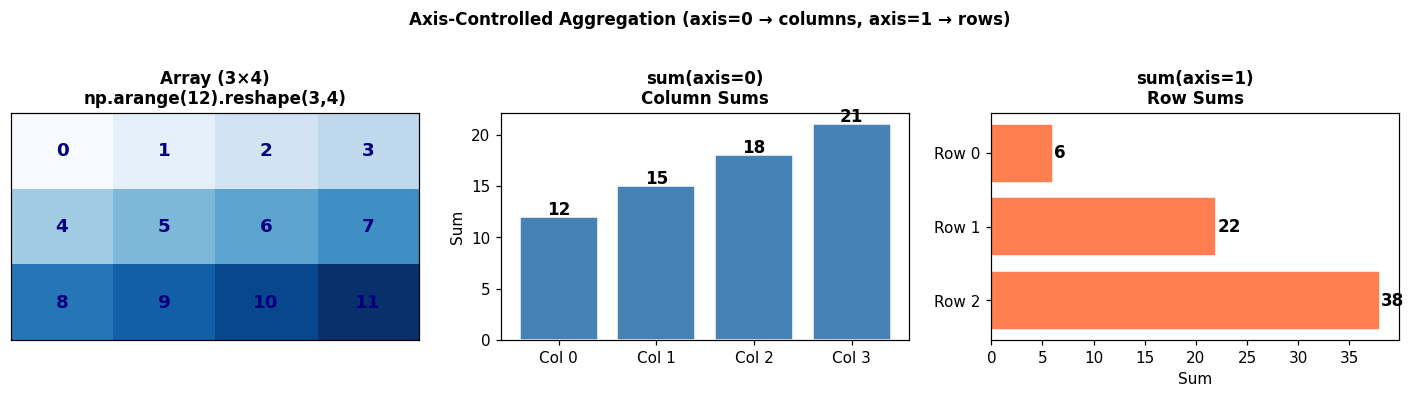

In [20]:
# Visualize axis operations
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

# Heatmap of array
im = axes[0].imshow(data, cmap='Blues', aspect='auto')
for r in range(3):
    for c in range(4):
        axes[0].text(c, r, str(data[r, c]), ha='center', va='center',
                     fontsize=12, fontweight='bold', color='navy')
axes[0].set_title('Array (3×4)\nnp.arange(12).reshape(3,4)', fontweight='bold')
axes[0].set_xticks([]); axes[0].set_yticks([])

# Column sums (axis=0)
col_sums = data.sum(axis=0)
axes[1].bar(range(4), col_sums, color='steelblue', edgecolor='white')
for i, v in enumerate(col_sums):
    axes[1].text(i, v + 0.2, str(v), ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('sum(axis=0)\nColumn Sums', fontweight='bold')
axes[1].set_xticks(range(4))
axes[1].set_xticklabels([f'Col {i}' for i in range(4)])
axes[1].set_ylabel('Sum')

# Row sums (axis=1)
row_sums = data.sum(axis=1)
axes[2].barh(range(3), row_sums, color='coral', edgecolor='white')
for i, v in enumerate(row_sums):
    axes[2].text(v + 0.1, i, str(v), va='center', fontweight='bold', fontsize=11)
axes[2].set_title('sum(axis=1)\nRow Sums', fontweight='bold')
axes[2].set_yticks(range(3))
axes[2].set_yticklabels([f'Row {i}' for i in range(3)])
axes[2].set_xlabel('Sum')
axes[2].invert_yaxis()

plt.suptitle('Axis-Controlled Aggregation (axis=0 → columns, axis=1 → rows)',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('np_introspection.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Element-wise Operations — Vectorization vs. Python Loops

Python lists do not support element-wise arithmetic — multiplication of two lists concatenates them or raises a `TypeError`. NumPy arrays support vectorized operations: the entire operation executes in compiled C with no Python loop overhead.

In [21]:
# Python lists — arithmetic does NOT work element-wise
L1 = list(range(10))          # [0, 1, 2, ..., 9]
L2 = list(range(10, 0, -1))   # [10, 9, 8, ..., 1]

print('L1 :', L1)
print('L2 :', L2)
print()
print('L1 * 0 (list repeat)          :', L1 * 0)   # repeats the list 0 times → []
print()

# L1 * L2 raises TypeError — lists cannot be multiplied together
try:
    _ = L1 * L2
except TypeError as e:
    print(f'L1 * L2 raises TypeError: {e}')
    print('→ Python lists require explicit loops for element-wise operations.')

L1 : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
L2 : [10, 9, 8, 7, 6, 5, 4, 3, 2, 1]

L1 * 0 (list repeat)          : []

L1 * L2 raises TypeError: can't multiply sequence by non-int of type 'list'
→ Python lists require explicit loops for element-wise operations.


In [22]:
# Loop-based approach (the Python-list workaround)
L3 = []
for i, j in zip(L1, L2):
    L3.append(i * j)
print('Loop-based element-wise product :', L3)

Loop-based element-wise product : [0, 9, 16, 21, 24, 25, 24, 21, 16, 9]


In [23]:
# NumPy vectorized — no loops, clean syntax
array1 = np.array(L1)
array2 = np.array(L2)

print('array1            :', array1)
print('array2            :', array2)
print()
print('array1 * array2   :', array1 * array2)   # element-wise multiply
print('array1 + array2   :', array1 + array2)   # element-wise add
print('array1 / array2   :', np.round(array1 / array2, 3))  # element-wise divide

array1            : [0 1 2 3 4 5 6 7 8 9]
array2            : [10  9  8  7  6  5  4  3  2  1]

array1 * array2   : [ 0  9 16 21 24 25 24 21 16  9]
array1 + array2   : [10 10 10 10 10 10 10 10 10 10]
array1 / array2   : [0.    0.111 0.25  0.429 0.667 1.    1.5   2.333 4.    9.   ]


In [24]:
# Speed comparison: loop vs. vectorized
import time

big_L1 = list(range(1_000_000))
big_L2 = list(range(1_000_000, 0, -1))
big_A1 = np.array(big_L1)
big_A2 = np.array(big_L2)

# Loop timing
start = time.perf_counter()
[i * j for i, j in zip(big_L1, big_L2)]
loop_time = time.perf_counter() - start

# NumPy timing
start = time.perf_counter()
big_A1 * big_A2
numpy_time = time.perf_counter() - start

print(f'Loop time   : {loop_time*1000:.1f} ms')
print(f'NumPy time  : {numpy_time*1000:.1f} ms')
print(f'NumPy is ~{loop_time/numpy_time:.0f}× faster on 1M elements')

Loop time   : 270.4 ms
NumPy time  : 17.0 ms
NumPy is ~16× faster on 1M elements


---
## 9. Data Types — dtype, Type Coercion, and int8 Constraints

NumPy arrays are **homogeneous** — all elements share one data type (`dtype`). Assigning a value that does not fit the dtype triggers coercion (floats → int truncation) or a `ValueError` (strings → int).

In [25]:
# Default dtype (int64 on most systems)
darray = np.arange(100)
print('dtype (default) :', darray.dtype)   # int64
print('Array[:10]      :', darray[:10])
print()

# Explicit int8 dtype (range: -128 to 127)
darray_int8 = np.arange(100, dtype=np.int8)
print('dtype (int8)    :', darray_int8.dtype)
print('Array[:10]      :', darray_int8[:10])

dtype (default) : int64
Array[:10]      : [0 1 2 3 4 5 6 7 8 9]

dtype (int8)    : int8
Array[:10]      : [0 1 2 3 4 5 6 7 8 9]


In [26]:
# Attempting to assign a string to an int8 array → ValueError
try:
    darray_int8[14] = 'a'
except ValueError as e:
    print(f'ValueError: {e}')
    print('→ int8 arrays cannot store strings. NumPy enforces type homogeneity.')

ValueError: invalid literal for int() with base 10: 'a'
→ int8 arrays cannot store strings. NumPy enforces type homogeneity.


In [27]:
# Assigning a float to int8 → silent truncation (no error, decimal dropped)
darray_int8[14] = 0.9      # silently truncates to 0
print('darray_int8[14] after assigning 0.9 :', darray_int8[14])
print('→ Float truncated to integer. 0.9 becomes 0.')
print()

# dtype comparison table
dtypes_info = [
    ('np.int8',   np.iinfo(np.int8).min,   np.iinfo(np.int8).max,   1),
    ('np.int16',  np.iinfo(np.int16).min,  np.iinfo(np.int16).max,  2),
    ('np.int32',  np.iinfo(np.int32).min,  np.iinfo(np.int32).max,  4),
    ('np.int64',  np.iinfo(np.int64).min,  np.iinfo(np.int64).max,  8),
    ('np.float32',np.finfo(np.float32).min,np.finfo(np.float32).max,4),
    ('np.float64',np.finfo(np.float64).min,np.finfo(np.float64).max,8),
]
print(f'{"dtype":<12} {"Min":>25} {"Max":>25} {"Bytes":>6}')
print('-' * 72)
for name, mn, mx, b in dtypes_info:
    print(f'{name:<12} {mn:>25} {mx:>25} {b:>6}')

darray_int8[14] after assigning 0.9 : 0
→ Float truncated to integer. 0.9 becomes 0.

dtype                              Min                       Max  Bytes
------------------------------------------------------------------------
np.int8                           -128                       127      1
np.int16                        -32768                     32767      2
np.int32                   -2147483648                2147483647      4
np.int64          -9223372036854775808       9223372036854775807      8
np.float32     -3.4028234663852886e+38    3.4028234663852886e+38      4
np.float64    -1.7976931348623157e+308   1.7976931348623157e+308      8


---
## 10. Broadcasting — Shape Compatibility Rules

Broadcasting allows NumPy to perform arithmetic on arrays of **different shapes** by automatically expanding the smaller array to match the larger one — without copying data. The rules:
1. Arrays are compared element-wise from the **trailing** (rightmost) dimension.
2. Two dimensions are compatible if they are **equal** or one of them is **1**.
3. Arrays with fewer dimensions are prepended with size-1 dimensions.

In [28]:
A1 = np.array([[1, 2, 3],
               [4, 5, 6],
               [7, 8, 9]])

# Case 1: same-shape arrays (3×3 + 3×3)
A2_full = np.ones((3, 3), dtype=int)
print('A1 + A2 (3×3 + 3×3):')
print(A1 + A2_full)
print()

A1 + A2 (3×3 + 3×3):
[[ 2  3  4]
 [ 5  6  7]
 [ 8  9 10]]



In [29]:
# Case 2: 1-D array broadcast across rows (3×3 + 1×3)
A2_row = np.array([1, 1, 1])
print('A1 + A2_row (3×3 + [1,1,1]):')
print(A1 + A2_row)
print()

# Case 3: scalar broadcast to every element
print('A1 + 1 (scalar broadcast):')
print(A1 + 1)

A1 + A2_row (3×3 + [1,1,1]):
[[ 2  3  4]
 [ 5  6  7]
 [ 8  9 10]]

A1 + 1 (scalar broadcast):
[[ 2  3  4]
 [ 5  6  7]
 [ 8  9 10]]


In [30]:
# Case 4: 3-D broadcasting (2,1,5) - (2,7,1) → output shape (2,7,5)
A4 = np.arange(10).reshape(2, 1, 5)
A5 = np.arange(14).reshape(2, 7, 1)

print('A4 shape:', A4.shape)
print('A5 shape:', A5.shape)

A6 = A4 - A5
print('A4 - A5 shape (broadcast result):', A6.shape)
print('A6[0]:')
print(A6[0])   # show first 2-D slice

A4 shape: (2, 1, 5)
A5 shape: (2, 7, 1)
A4 - A5 shape (broadcast result): (2, 7, 5)
A6[0]:
[[ 0  1  2  3  4]
 [-1  0  1  2  3]
 [-2 -1  0  1  2]
 [-3 -2 -1  0  1]
 [-4 -3 -2 -1  0]
 [-5 -4 -3 -2 -1]
 [-6 -5 -4 -3 -2]]


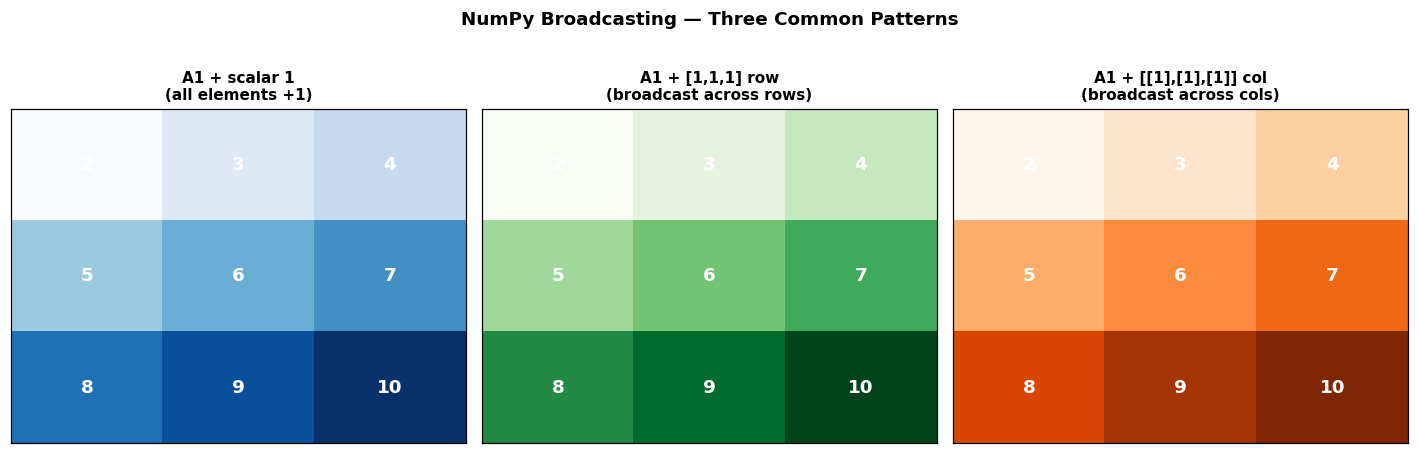

In [31]:
# Visualize broadcasting: scalar and 1-D cases
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

A = np.array([[1,2,3],[4,5,6],[7,8,9]])
cases = [
    (A + 1,            '+ scalar 1\n(all elements +1)',     'Blues'),
    (A + np.array([1,1,1]), '+ [1,1,1] row\n(broadcast across rows)', 'Greens'),
    (A + np.array([[1],[1],[1]]), '+ [[1],[1],[1]] col\n(broadcast across cols)', 'Oranges'),
]
for ax, (result, title, cmap) in zip(axes, cases):
    im = ax.imshow(result, cmap=cmap, aspect='auto')
    for r in range(3):
        for c in range(3):
            ax.text(c, r, str(result[r,c]), ha='center', va='center',
                    fontsize=12, fontweight='bold', color='white')
    ax.set_title(f'A1 {title}', fontsize=10, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('NumPy Broadcasting — Three Common Patterns', fontsize=12,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('np_broadcasting.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. DataFrames to NumPy Arrays — Real-World Workflow

In production analytics, data typically arrives as a pandas DataFrame (from CSV, SQL, or APIs). Converting to NumPy enables high-performance numerical computation — particularly useful for feeding data into scikit-learn models or performing matrix operations that pandas does not natively support.

In [32]:
# Load Telco Customer Churn dataset
url = 'https://drive.google.com/file/d/1AOceeQ7kCbyMXb8dE72tkVhRPt_UH3Y4/view?usp=sharing'
file_id = url.split('/')[-2]
download_link = 'https://drive.google.com/uc?export=download&id=' + file_id
data = pd.read_csv(download_link)

# Fallback if Drive quota is reached:
# data = pd.read_csv('https://raw.githubusercontent.com/marineevy/datasets/main/telco_churn.csv')
# data = pd.read_csv('CustomerChurn.csv')

print(f'DataFrame shape : {data.shape}')
print(f'Columns         : {data.columns.tolist()}')
data.head(2)

DataFrame shape : (7043, 24)
Columns         : ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Customer Feedback', 'Sentiment', 'Feedback Date']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Customer Feedback,Sentiment,Feedback Date
0,07882-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,The service is decent but still figuring out i...,Neutral,2019-02-18 21:04:18.439154223
1,15062-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,Very pleased with the reliability and cost-eff...,Positive,2023-04-09 09:22:20.288316155


In [33]:
# Convert entire DataFrame to NumPy (mixed types → dtype object)
full_array = data.to_numpy()
print('Full array dtype :', full_array.dtype)   # object — because of mixed types
print('Full array shape :', full_array.shape)
print('Sample row       :', full_array[0, :4])

Full array dtype : object
Full array shape : (7043, 24)
Sample row       : ['07882-VHVEG' 'Female' 0 'Yes']


In [34]:
# Select only numerical columns (excludes object/string columns)
num_cols = data.select_dtypes(exclude='object').columns.tolist()
print('Numerical columns:', num_cols)
print()

num_data_array = data.select_dtypes(exclude='object').to_numpy()
print('Numerical array dtype :', num_data_array.dtype)
print('Numerical array shape :', num_data_array.shape)
print()
print('First 5 rows:')
print(num_data_array[:5])

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Numerical array dtype : float64
Numerical array shape : (7043, 4)

First 5 rows:
[[0.00000e+00 1.00000e+00 2.98500e+01 2.98500e+01]
 [0.00000e+00 3.40000e+01 5.69500e+01 1.88950e+03]
 [0.00000e+00 2.00000e+00 5.38500e+01 1.08150e+02]
 [0.00000e+00 4.50000e+01 4.23000e+01 1.84075e+03]
 [0.00000e+00 2.00000e+00 7.07000e+01 1.51650e+02]]


In [35]:
# Column-wise statistics on the numerical array
print('Column means (axis=0):')
raw_means = num_data_array.mean(axis=0)
for col, val in zip(num_cols, raw_means):
    print(f'  {col:<20}: {val}')

print()
# TotalCharges contains NaN → use nanmean to ignore missing values
print('Column means using np.nanmean (NaN-safe):')
nan_safe_means = np.nanmean(num_data_array, axis=0)
for col, val in zip(num_cols, nan_safe_means):
    print(f'  {col:<20}: {val:.4f}')

print()
print('Column maxima (NaN-safe):')
nan_safe_max = np.nanmax(num_data_array, axis=0)
for col, val in zip(num_cols, nan_safe_max):
    print(f'  {col:<20}: {val}')

Column means (axis=0):
  SeniorCitizen       : 0.1621468124378816
  tenure              : 32.37114865824223
  MonthlyCharges      : 64.76169246059918
  TotalCharges        : nan

Column means using np.nanmean (NaN-safe):
  SeniorCitizen       : 0.1621
  tenure              : 32.3711
  MonthlyCharges      : 64.7617
  TotalCharges        : 2283.3004

Column maxima (NaN-safe):
  SeniorCitizen       : 1.0
  tenure              : 72.0
  MonthlyCharges      : 118.75
  TotalCharges        : 8684.8


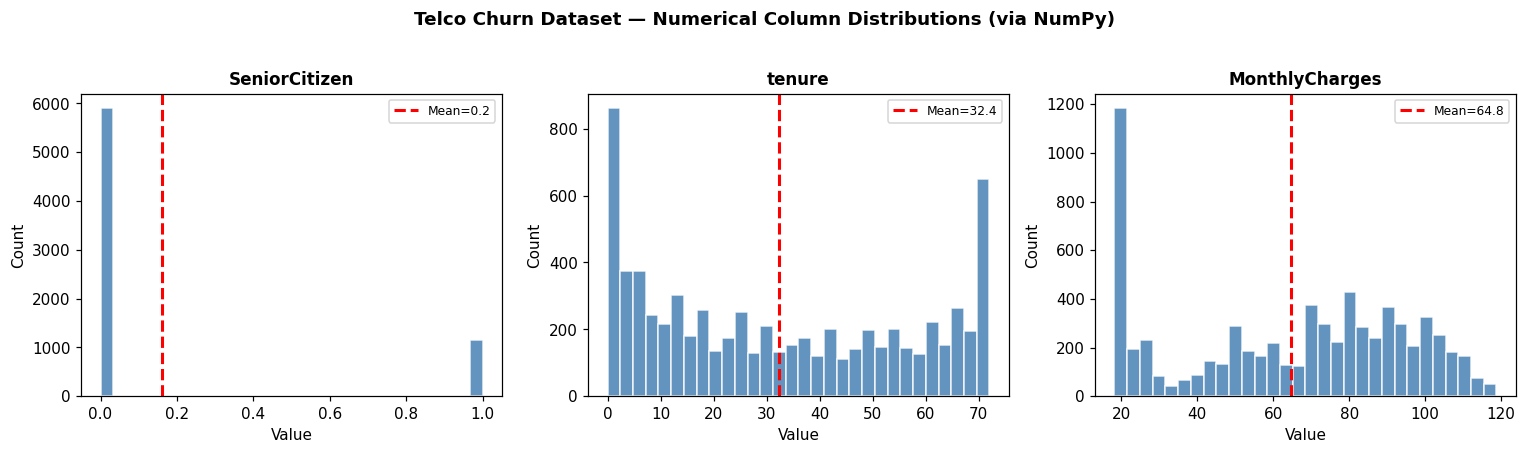

In [36]:
# Visualize the three numerical columns
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Detect NaN-free columns for clean histograms
for ax, col in zip(axes, num_cols):
    clean = num_data_array[:, num_cols.index(col)]
    clean = clean[~np.isnan(clean.astype(float))]  # remove NaNs
    ax.hist(clean.astype(float), bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_xlabel('Value')
    ax.axvline(np.nanmean(clean.astype(float)), color='red',
               linestyle='--', lw=2, label=f'Mean={np.nanmean(clean.astype(float)):.1f}')
    ax.legend(fontsize=8)

plt.suptitle('Telco Churn Dataset — Numerical Column Distributions (via NumPy)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('np_dataframe_arrays.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary

| Concept | Key Function / Pattern | What It Does |
|---|---|---|
| Array creation | `np.array`, `np.zeros`, `np.arange`, `np.linspace` | Build arrays from scratch |
| Shape inspection | `.shape`, `.ndim`, `.size` | Understand array structure |
| Reshape | `.reshape(rows, cols)` | Rearrange dimensions (total elements unchanged) |
| Slicing | `arr[2, 3]`, `arr[:, 3]`, `arr[0:2, -3:]` | Select elements/sub-arrays |
| Boolean filtering | `arr[arr < 5]`, `arr[(a<5)&(a%2==0)]` | Condition-based element selection |
| View vs. copy | `arr[...]` → view · `arr[...].copy()` → independent | Control memory sharing |
| Aggregation | `.max()`, `.sum(axis=0)`, `.mean()`, `.std(axis=1)` | Axis-aware statistics |
| Vectorization | `array1 * array2` | Element-wise ops without loops |
| Data types | `dtype=np.int8`, `np.float64` | Memory-efficient storage with type enforcement |
| Broadcasting | `arr + scalar`, `arr + 1d_array` | Shape-compatible arithmetic without copies |
| DataFrame → Array | `.to_numpy()`, `np.nanmean()` | High-performance numerical computation from pandas |

**Performance takeaway:** NumPy operations on 1,000,000 elements run in milliseconds. Equivalent Python loops take hundreds of milliseconds. For any numerical workflow at scale — ML feature engineering, financial modeling, signal processing — NumPy is the correct tool.